## Métodos de AM tradicionais : Naive Bayes e kNN

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pydot

%matplotlib inline

In [4]:
from IPython.display import Image, display, display_html

def view_pydot(pdot):
    plt = Image(pdot.create_png())
    display(plt)

import networkx as nx

def plotg(g):
    to_pdot = nx.drawing.nx_pydot.to_pydot
    pdot = to_pdot(g)
    view_pydot(pdot)

def display_side_by_side(*args):
    html_str=''
    for df in args:
        html_str+=df.to_html()
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [5]:
from collections.abc import MutableMapping

class CondProbTable(MutableMapping):
    """Conditional probabily table represented as a dictionary of dictionaries.
    If P is a CondProbTable, P['A|B'] is the same as P['A']['B']."""

    def __init__(self, *args, **kwargs):
        self.store = dict()
        self._update(dict(*args, **kwargs))

    def __getitem__(self, key):
        if '|' in key:
            [key1, key2] = key.split('|')
            return self.store[key1][key2]
        else:
            return self.store[key][key]

    def __setitem__(self, key, value):
        if '|' in key:
            [key1, key2] = key.split('|')
            if key1 not in self.store:
                self.store[key1] = dict()
            self.store[key1][key2] = value
        elif type(value) is not dict:
            if key not in self.store:
                self.store[key] = dict()
            self.store[key][key] = value
        else:
            self.store[key] = value

    def __delitem__(self, key):
        del self.store[key]

    def __iter__(self):
        return iter(self.store)

    def __len__(self):
        return len(self.store)

    def __repr__(self):
        dct = self.store.__repr__()
        return '%s(%s)' % (type(self).__name__, dct)

    def _update(self, dct):
        self.update(dct)

def dist_conjunta(A, B, normalize = False, laplace = 0, prev = None):
    # get crosstab
    ct = pd.crosstab(A, B)
    # applies Laplace's smoothing technique
    ct = ct + laplace
    # normlize columns
    if normalize:
        for c in ct:
            ct[c] = ct[c]/ct[c].sum()
    # rename cols and index so that variable name includes "var="
    ct.rename(columns = dict(zip(ct.columns, [B.name + '=' + c for c in ct.columns])), inplace = True)
    ct.index = [A.name + '=' + c for c in ct.index]
    # show table
    display(ct)
    # return CPT a dictionary so that it is easier to access P(A|B)
    if prev is None:
        return CondProbTable(ct.T.to_dict())
    else:
        prev._update(ct.T.to_dict())
        return prev

### Dados

In [6]:
weather = {'ceu': ['ensolarado', 'ensolarado', 'nublado', 'chuvoso', 'chuvoso', 'chuvoso', 'nublado',
                     'ensolarado', 'ensolarado', 'chuvoso', 'ensolarado', 'nublado', 'nublado', 'chuvoso'],
          'temp': ['quente', 'quente', 'quente', 'media', 'fria', 'fria', 'fria',
                        'media', 'fria', 'media', 'media', 'media', 'quente', 'media'],
          'umidade': ['alta', 'alta', 'alta', 'alta', 'normal', 'normal', 'normal',
                     'alta', 'normal', 'normal', 'normal', 'alta', 'normal', 'alta'],
          'vento': ['F', 'V', 'F', 'F', 'F', 'V', 'V',
                  'F', 'F', 'F', 'V', 'V', 'F', 'V'],
          'jogar': ['F', 'F', 'V', 'V', 'V', 'F', 'V',
                 'F', 'V', 'V', 'V', 'V', 'V', 'F']}
wdf = pd.DataFrame(weather)[['ceu', 'temp', 'umidade', 'vento', 'jogar']]

### Bayesianos -- o algoritmo NaiveBayes

O algoritmo NaiveBayes usa diretamente a Teoria de Decisão Bayesiana, ou seja, dada a instância $I$ e classes possíveis $C$, a classe mais provável é aquela que minimiza o risco de classificação de acordo com a regra de Bayes, ou seja (onde $\eta$ é uma constante de normalização):

$$
\begin{align}
c* & = \arg \max_c P(C = c|I) \\
& = \arg \max_c {\color{green}{\eta}} {\color{red}{P(I|C = c)}} {\color{magenta}{P(C = c)}} \\
& \sim \arg \max_c {\color{blue}{\log}} {\color{red}{P(I|C = c)}} + {\color{blue}{\log}} {\color{magenta}{P(C = c)}}
\end{align}
$$

Para estimar ${\color{red}{P(I|C = c)}}$, o algoritmo assume que se a instância $I$ é representada pelos atributos $a_1, a_2, ..., a_n$, então ${\color{red}{P(I|C = c)}} \approx \prod_{i=1}^{n} P(a_i | C = c) \sim \sum_{i=1}^{n} \log P(a_i | C = c)$. Para tanto, é usada uma abordagem de estimativa de risco empírico, ou seja, as probabilidades ${\color{red}{P(I|C = c)}}$ e ${\color{magenta}{P(C = c)}}$ são estimadas da coleção de treino. A equação resultante se torna:

$$
\begin{align}
c* \sim \arg \max_c \big({\color{red}{\sum_{i=1}^{n} \log P(a_i | C = c)}}\big) + {\color{blue}{\log}} {\color{magenta}{P(C = c)}}
\end{align}
$$

Vamos considerar a coleção weather, supondo que os dados que temos correspondem a uma amostra (de treino) de uma população maior de jogos.

Primeiro, estimamos as probabilidades $P(jogar=V)$ e $P(jogar=F)$ diretamente da distribuição da variável jogar:

In [7]:
wdf.jogar.value_counts().to_dict()

{'V': 9, 'F': 5}

In [8]:
P = CondProbTable([])

In [9]:
P['jogar=V']=wdf.jogar.value_counts(normalize = True).to_dict()['V']
P['jogar=F']=wdf.jogar.value_counts(normalize = True).to_dict()['F']

Logo, $P(jogar=V) = \frac{9}{9+5} = 0.64$ e $P(jogar=F) = \frac{5}{9+5} = 0.36$.

No caso de $P(a_i | C = c)$, podemos fazer estimativas apartir das ocorrências conjuntas de $a_i$ e $C$. Por exemplo, para ceu, temos:

In [10]:
pd.crosstab(wdf.ceu, wdf.jogar, margins=True)

jogar,F,V,All
ceu,,,
chuvoso,2,3,5
ensolarado,3,2,5
nublado,0,4,4
All,5,9,14


Desta tabela, por exemplo, podemos estimar $P(ceu = nublado~|~jogar = V) = 4/9 = 0.44$. Da mesma forma, $P(ceu = nublado~|~jogar = F) = 0/5 = 0$.

Para este segundo caso, contudo, note que estamos estimando do treino que é impossível se observar um jogo de tênis com o céu nublado. De fato, desde que estamos fazendo estimativas com base em uma amostra da população real, não deveríamos ser tão rigorosos e supor que a probabilidade de um evento que não vimos é zero. Podemos imaginar que este é apenas um evento raro, mas não necessariamente impossível. Assim, devemos considerar a axistência de uma pequena probabilidade para o evento. Como regra geral, para evitar probabilidades nulas, vamos aplicar alguma técnica de suavização: por exemplo, adicionar 1 a todos os contadores, o que é conhecido como técnica de suavização de Laplace:

In [11]:
original = pd.crosstab(wdf.ceu, wdf.jogar)
apos_laplace = pd.crosstab(wdf.ceu, wdf.jogar) + 1
display_side_by_side(original, apos_laplace)

jogar,F,V
ceu,,
chuvoso,2,3
ensolarado,3,2
nublado,0,4
jogar,F,V
ceu,,
chuvoso,3,4
ensolarado,4,3
nublado,1,5


In [12]:
apos_laplace['P(ceu|F)'] = apos_laplace['F'] / apos_laplace['F'].sum()
apos_laplace['P(ceu|V)'] = apos_laplace['V'] / apos_laplace['V'].sum()

Uma questão interessante é se há ou não necessidade de aplicar Laplace às estimativas de classes. Se aplicarmos Laplace, temos:

$P(jogar=V) = \frac{9+1}{(9+1)+(5+1)} = 0.625$ e $P(jogar=F) = \frac{5+1}{(9+1)+(5+1)} = 0.375$.

In [13]:
wdf.jogar.value_counts(normalize=True)['V']

np.float64(0.6428571428571429)

Se aplicarmos o que vimos até agora para todas as variáveis, temos (desta vez usando meu método `dist_conjunta`):

In [14]:
for c in ['ceu', 'temp', 'umidade', 'vento']:
    P = dist_conjunta(wdf[c], wdf.jogar, laplace = 1, normalize = True, prev=P)

jogar,jogar=F,jogar=V
ceu=chuvoso,0.375,0.333333
ceu=ensolarado,0.500,0.250000
ceu=nublado,0.125,0.416667


jogar,jogar=F,jogar=V
temp=fria,0.250,0.333333
temp=media,0.375,0.416667
temp=quente,0.375,0.250000


jogar,jogar=F,jogar=V
umidade=alta,0.714286,0.363636
umidade=normal,0.285714,0.636364


jogar,jogar=F,jogar=V
vento=F,0.428571,0.636364
vento=V,0.571429,0.363636


Com todas as probabilidades estimadas do treino, podemos fazer inferência para novos casos de teste. Por exemplo, qual a probabilidade $P(jogar~|~I)$ para $I$ dado por:

$I$ = {ceu = ensolarado, temp = fria, umidade = alta, vento = V}

Para tanto precisamos calcular $P(jogar~|~I)=\eta~P(I~|~jogar)P(jogar)$:

In [15]:
P['jogar=V|I'] = (P['ceu=ensolarado|jogar=V'] *
                  P['temp=fria|jogar=V'] *
                  P['umidade=alta|jogar=V'] *
                  P['vento=V|jogar=V'] *
                  P['jogar=V'])
P['jogar=F|I'] = (P['ceu=ensolarado|jogar=F'] *
                  P['temp=fria|jogar=F'] *
                  P['umidade=alta|jogar=F'] *
                  P['vento=V|jogar=F'] *
                  P['jogar=F'])
eta = 1 / (P['jogar=V|I'] + P['jogar=F|I'])

eta*P['jogar=V|I'], eta*P['jogar=F|I']

(0.27993334920257085, 0.7200666507974292)

Como podemos ver $P(I|jogar=V) < P(I|jogar=F)$. Logo, dado $I$, é mais provável que _não_ haja jogo.

#### E para o caso de atributos numericos? use uma estimativa Gaussiana

Para atributos numéricos, uma estimativa uniforme não é adequada, uma vez que, para cada valor possível, ela será baseada em uma pequena amostra. Uma alternativa é usar uma estimativa contínua. Por exemplo, supondo que a variável numérica segue uma distribuição Gaussiana, podemos obter estimativas de probabilidade para os valores usando a função de desensidade de probabilidade da distribuição normal:

$$f(x|\mu, \sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{\frac{-(x-\mu)^2}{2 \sigma^2}}$$

Em python:

In [16]:
gaussian_prob = lambda x, mu, sigma: 1./np.sqrt(2. * np.pi * sigma**2) * np.exp(-(x-mu)**2/(2*sigma**2))

Por exemplo, para o exemplo abaixo:

In [17]:
weathern = {'ceu': ['ensolarado', 'ensolarado', 'nublado', 'chuvoso', 'chuvoso', 'chuvoso', 'nublado',
                     'ensolarado', 'ensolarado', 'chuvoso', 'ensolarado', 'nublado', 'nublado', 'chuvoso'],
          'temp': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0,
                          69.0, 75.0, 75.0, 72.0, 81.0, 71.0],
          'umidade': [85.0, 90.0, 86.0, 96.0, 80.0, 70.0, 65.0,
                       95.0, 70.0, 80.0, 70.0, 90.0, 75.0, 91.0],
          'vento': ['F', 'V', 'F', 'F', 'F', 'V', 'V',
                  'F', 'F', 'F', 'V', 'V', 'F', 'V'],
          'jogar': ['F', 'F', 'V', 'V', 'V', 'F', 'V',
                 'F', 'V', 'V', 'V', 'V', 'V', 'F']}
wndf = pd.DataFrame(weathern)[['ceu', 'temp', 'umidade', 'vento', 'jogar']]

Podemos estimar os seguintes parâmetros $\mu$ e $\sigma$ para os atributos temperatura e umidade:

In [18]:
tempFmu, tempFsigma = wndf[wndf.jogar=='F'].temp.mean(), wndf[wndf.jogar=='F'].temp.std()
tempVmu, tempVsigma = wndf[wndf.jogar=='V'].temp.mean(), wndf[wndf.jogar=='V'].temp.std()

O que representariam as seguintes distribuições, considerando o caso particular da temperatura:

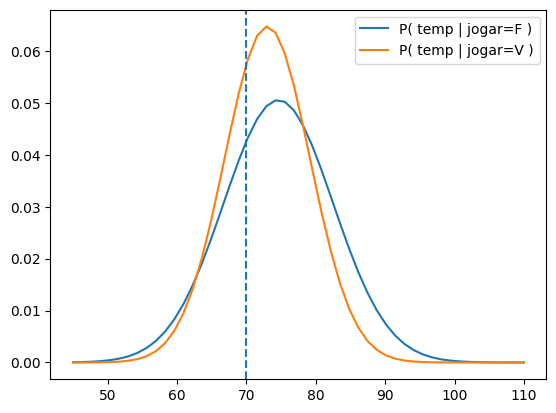

In [19]:
x = np.linspace(45, 110)
plt.plot(x, stats.norm.pdf(x, tempFmu, tempFsigma), label='P( temp | jogar=F )')
plt.plot(x, stats.norm.pdf(x, tempVmu, tempVsigma), label='P( temp | jogar=V )')
plt.axvline(x=70, linestyle = '--')
plt.legend()

In [20]:
gaussian_prob(70, tempFmu, tempFsigma), gaussian_prob(70, tempVmu, tempVsigma),

(np.float64(0.04264937407110744), np.float64(0.05748951672082569))

Neste caso, para a temperatura 70 graus, é mais provável jogar = V. Para um exemplo mais complexo, vamos considerar o caso:

$I$ = {ceu = ensolarado, temp = 73, umidade = 90, vento = V}

Primeiro estimamos os parâmetros para temp = 73 e umidade = 90 e, em seguida, suas probabilidades:

In [21]:
tempFmu, tempFsigma = wndf[wndf.jogar=='F'].temp.mean(), wndf[wndf.jogar=='F'].temp.std()
tempVmu, tempVsigma = wndf[wndf.jogar=='V'].temp.mean(), wndf[wndf.jogar=='V'].temp.std()

umFmu, umFsigma = wndf[wndf.jogar=='F'].umidade.mean(), wndf[wndf.jogar=='F'].umidade.std()
umVmu, umVsigma = wndf[wndf.jogar=='V'].umidade.mean(), wndf[wndf.jogar=='V'].umidade.std()

print(gaussian_prob(73, tempFmu, tempFsigma), gaussian_prob(73, tempVmu, tempVsigma))
print(gaussian_prob(90, umFmu, umFsigma), gaussian_prob(90, umVmu, umVsigma))

0.04951572453448171 0.06471698367586758
0.037986049936266336 0.022127532669816825


Agora, podemos estimar os demais valores:

\begin{align}
P(I|jogar = V) P(jogar = V) &= P(ceu = ensolarado~|~jogar = V) \\
&\times P(temp = 73~|~jogar = V) \\
&\times P(umidade = 90~|~jogar = V) \\
&\times P(vento = true~|~jogar = V)~P(jogar = V) \\
&= 0.25 \times 0.33 \times 0.065 \times 0.022 \times 0.625 \\
&= 7.3734375e-05
\end{align}

\begin{align}
P(I|jogar = F) P(jogar = F) &= P(ceu = ensolarado~|~jogar = F) \\
&\times P(temp = 73~|~jogar = F) \\
&\times P(umidade = 90~|~jogar = F) \\
&\times P(vento = true~|~jogar = F)~P(jogar = F) \\
&= 0.50 \times 0.25 \times 0.049 \times 0.038 \times 0.375 \\
&= 8.728125e-05
\end{align}

Como podemos ver $P(I|jogar=V) \approx \frac{7.3734375e-05}{7.3734375e-05+8.728125e-05} = 0.46$ < $P(I|jogar=F) \approx \frac{8.728125e-05}{7.3734375e-05+8.728125e-05} = 0.54$. Logo, dado $I$, é mais provável que _não_ haja jogo.

#### Naive Bayes e hiperplanos de separação

Imagine que gostaríamos de separar SPAM de HAM usando NB. Em particular, temos que tomar uma decisão relacionada com a mensagem `gratis gratis clique aqui aqui aqui`. Sem vetorização, podemos tratar cada palavra como um atributo e resolver a decisão:

$P(SPAM) P(gratis|SPAM) P(gratis|SPAM) P(clique|SPAM) P(aqui|SPAM) P(aqui|SPAM) P(aqui|SPAM) >
P(HAM) P(gratis|HAM) P(gratis|HAM) P(clique|HAM) P(aqui|HAM) P(aqui|HAM) P(aqui|HAM)$?

Isto equivale a:

$
=\log P(SPAM) + \log P(gratis|SPAM) + \log P(gratis|SPAM) + \log P(clique|SPAM) + \log P(aqui|SPAM) + \log P(aqui|SPAM) + \log P(aqui|SPAM) >
\log P(HAM)  + \log P(gratis|HAM) + \log P(gratis|HAM) + \log P(clique|HAM) + \log P(aqui|HAM) + \log P(aqui|HAM) + \log P(aqui|HAM)\\
= \log P(SPAM) + 2 \log P(gratis|SPAM) + \log P(clique|SPAM) + 3 \log P(aqui|SPAM) > \log P(HAM) + 2 \log P(gratis|HAM) + \log P(clique|HAM) + 3 \log P(aqui|HAM) \\
= 2 (\log P(gratis|SPAM) - \log P(gratis|HAM)) + (\log P(clique|SPAM) - \log P(clique|HAM)) + 3 (\log P(aqui|SPAM) - \log P(aqui|HAM)) + \log P(SPAM) - \log P(HAM) > 0
$

Com ${\bf w} = \begin{pmatrix} 2\\ 1\\ 3 \end{pmatrix}$, ${\bf x} = \begin{pmatrix} x_0~x_1~x_2 \end{pmatrix}$, onde $x_i = \log P(x_i|SPAM) - \log P(x_i|HAM)$ e $b = \log P(SPAM) - \log P(HAM)$, observamos que a decisão do Naive Bayes corresponde a encontrar um plano de separação linear:

${\bf w} \dot~{\bf x} + b > 0$

#### Conclusões

Método linear baseado em toeria de decisão Bayesiana. Aspectos fundamentais sobre o Naive Bayes:

* Método naturalmente incremental, já que dada uma nova instância, não é preciso recalcular todas as probabilidades, mas apenas atualizar as que foram afetadas. Apropriado para aplicações online;
* Aplicação direta da Teoria de Decisão Bayesiana e da Teoria de Risco Empírico;
* Embora seja um método ok para classificação, não é muito bom como estimador (ou seja, embora possa até acertar as classes, suas estimativas de probabilidade não são as melhores);
* Primeiro tratamento do problema como um problema de incerteza. No futuro, isto vai abrir caminho para, além da detecção de padrões, a sua geração;
* Estimativas comumente empregadas para $P(x_i|y)$ incluem:
    * _Gaussiana_ (vista antes): $P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma^2_y}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma^2_y}\right)$, com $\sigma_y$ e $\mu_y$ estimados via máxima verossimelhança.
    * _Multinomial_: no caso de texto, é comum assumirmos que a entrada seque uma distribuição multinomial parametrizada por $\theta_y = (\theta_{y1},\ldots,\theta_{yn})$, para cada classe $y$, onde $n$ é o número de features (o tamanho do vocabulário) e $P(x_i \mid y)$ á a probabilidade de $x_i$ aparecer em uma amostra pertencente a $y$. $\theta_y$ é estimada como a verossimelhança máxima com suavização, ou seja, $\hat{\theta}_{yi} = \frac{ N_{yi} + \alpha}{N_y + \alpha n}$, onde $N_{yi}$ é o número de vezes que $x_i$ aparece em uma amostra de $y_i$ (no treino), $N_y$ é o total de palavras vistas em $y_i$ (a soma de todos $N_{yi}$) e a $\alpha$ é o incremento de suavização.
    * _Bernoulli_: para casos em que assumimos que a entrada segue uma distribuição de Bernoulli. Nesses casos, os valores das features são binários e $P(x_i \mid y) = P(i \mid y) x_i + (1 - P(i \mid y)) (1 - x_i)$, onde $i$ (0 ou 1) é o valor da feature $x_i$.

## Métodos baseados em instâncias -- $k$ Nearest Neighbors

Estes são métodos muito simples de classificação e regressão baseados na ideia de se encontrar um conjunto pré-definido de casos de treino similares a uma nova instância (os vizinhos) e prever a nova instância com base neles. O tamanho da vizinhança pode ser tanto dada em termos de um número fixo $k$ quanto em termos de um raio de distância. A distância pode ser medida por qualquer métrica, por exemplo, a euclidiana. Esses métodos não empregam técnicas de generalização já que eles lembram de todos os dados do treino.

Para um exemplo deste método, dada a coleção abaixo, qual a classe de uma instância `<ceu = ensolarado, temp = media, umidade = alta, vento = V>`, considerando $k$ = 1, 3, 5?

In [22]:
wdf

,ceu,temp,umidade,vento,jogar
0,ensolarado,quente,alta,F,F
1,ensolarado,quente,alta,V,F
2,nublado,quente,alta,F,V
3,chuvoso,media,alta,F,V
4,chuvoso,fria,normal,F,V
5,chuvoso,fria,normal,V,F
6,nublado,fria,normal,V,V
7,ensolarado,media,alta,F,F
8,ensolarado,fria,normal,F,V
9,chuvoso,media,normal,F,V


Para calcular o kNN vamos considerar a distância de Manhattan para o exemplo dado:

In [23]:
exemplo = np.array(['ensolarado', 'media', 'alta', 'V'])

In [24]:
def manhattan(row, vec):
    return 1 - (vec==row).sum()/row.shape[0]

In [25]:
wdf['dist'] = wdf.apply(lambda v: manhattan(v[:-1].values, exemplo), axis = 1)

Para $k$=1, temos, jogar = F:

In [26]:
wdf.sort_values('dist').head(1)

,ceu,temp,umidade,vento,jogar,dist
1,ensolarado,quente,alta,V,F,0.25


Para $k$=3, temos jogar = F com 67% de certeza (2/3 dos vizinhos):

In [27]:
wdf.sort_values('dist').head(3)

,ceu,temp,umidade,vento,jogar,dist
1,ensolarado,quente,alta,V,F,0.25
7,ensolarado,media,alta,F,F,0.25
10,ensolarado,media,normal,V,V,0.25


Para $k$=5, temos jogar = F com 60% de certeza (3/5 dos vizinhos):

In [28]:
wdf.sort_values('dist').head(5)

,ceu,temp,umidade,vento,jogar,dist
1,ensolarado,quente,alta,V,F,0.25
7,ensolarado,media,alta,F,F,0.25
10,ensolarado,media,normal,V,V,0.25
11,nublado,media,alta,V,V,0.25
13,chuvoso,media,alta,V,F,0.25


#### Conclusões

O kNN consiste de uma família de métodos muito simples, muito usado como componente de diferentes outras técnicas (como estimativas de densidade). A maneira como uma decisão é inferida da vizinhança pode ou não considerar a similaridade dos vizinhos, através de ponderação. Implementações efetivas destes métodos devem recuperar as informações de treino com a ajuda de alguma estrutura de busca eficiente como uma KD-Tree ou uma Ball Tree.